# Market Data

## Pulling Data from Yahoo Finance

As used in Gidea & Katz, we are going to pull data of S&P 500, DJIA, NASDAQ, and Russell 2000 from 1999 to 2021 to create our multidimensional time series. It covers the dot-com crash (2000), the 2008 financial crisis, and the COVID crash (2020).

## Log return

We'll calculate log returns, they represent continuous compounding, you can easily add the log returns of multiple days together and it makes the assets comparable by normalization, this is an advantage compared to raw prices. Its formula is 

$$ R_i = \ln\left(\frac{P_i}{P_{i-1}}\right)$$



In [67]:
import numpy as np
import pandas as pd
import yfinance as yf
import math as mt
import matplotlib.pyplot as plt

In [ ]:
# Download historical data for the S&P 500, NASDAQ, Dow Jones Industrial Average, and Russell 2000 indices from 1999 to 2021

SP500 = yf.download("^GSPC", start="1999-01-01", end="2021-12-31")
NASDAQ = yf.download("^IXIC", start="1999-01-01", end="2021-12-31")
DJIA = yf.download("^DJI", start="1999-01-01", end="2021-12-31")
RUSSELL2000 = yf.download("^RUT", start="1999-01-01", end="2021-12-31")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
# S&P 500 returns
SP500_returns = np.log(SP500["Close"]/SP500["Close"].shift(1))

# NASDAQ returns
NASDAQ_returns = np.log(NASDAQ["Close"]/NASDAQ["Close"].shift(1))

# DJIA returns
DJIA_returns = np.log(DJIA["Close"]/DJIA["Close"].shift(1))

# Russell 2000 returns
RUSSELL2000_returns = np.log(RUSSELL2000["Close"]/RUSSELL2000["Close"].shift(1))


In [ ]:
# Combine the returns into a single DataFrame
market_returns = pd.concat([SP500_returns, NASDAQ_returns, DJIA_returns, RUSSELL2000_returns], axis=1)
print(market_returns.head())
print(market_returns.shape[0])

Ticker         ^GSPC     ^IXIC      ^DJI      ^RUT
1999-01-04       NaN       NaN       NaN       NaN
1999-01-05  0.013491  0.019385  0.013725  0.001968
1999-01-06  0.021899  0.030443  0.024797  0.013414
1999-01-07 -0.002053  0.002251 -0.000756  0.000093
1999-01-08  0.004212  0.007845  0.011007  0.007916
5787


In [ ]:
# Delete the rows with missing values
market_returns.dropna(inplace=True)
print(market_returns.head())
print(market_returns.shape[0])

Ticker         ^GSPC     ^IXIC      ^DJI      ^RUT
1999-01-05  0.013491  0.019385  0.013725  0.001968
1999-01-06  0.021899  0.030443  0.024797  0.013414
1999-01-07 -0.002053  0.002251 -0.000756  0.000093
1999-01-08  0.004212  0.007845  0.011007  0.007916
1999-01-11 -0.008830  0.016994 -0.002433  0.004396
5786


In [ ]:
# Rename the columns
market_returns.rename(columns={"^GSPC": "SP500", "^IXIC": "NASDAQ", "^DJI": "DJIA", "^RUT": "Russell2000"}, inplace=True)
print(market_returns.head())

Ticker         SP500    NASDAQ      DJIA  Russell2000
1999-01-05  0.013491  0.019385  0.013725     0.001968
1999-01-06  0.021899  0.030443  0.024797     0.013414
1999-01-07 -0.002053  0.002251 -0.000756     0.000093
1999-01-08  0.004212  0.007845  0.011007     0.007916
1999-01-11 -0.008830  0.016994 -0.002433     0.004396


## Visualization 

Now we make a visualization and view the prices and log returns behavior during crisis

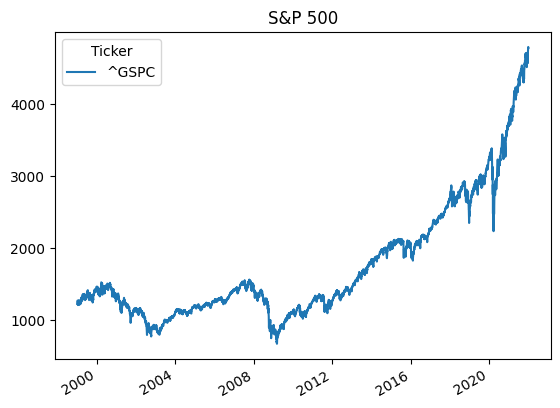

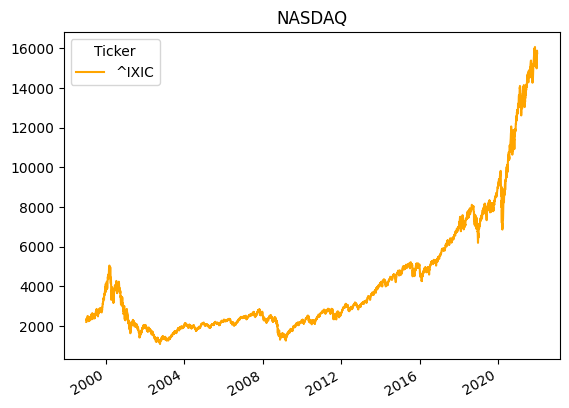

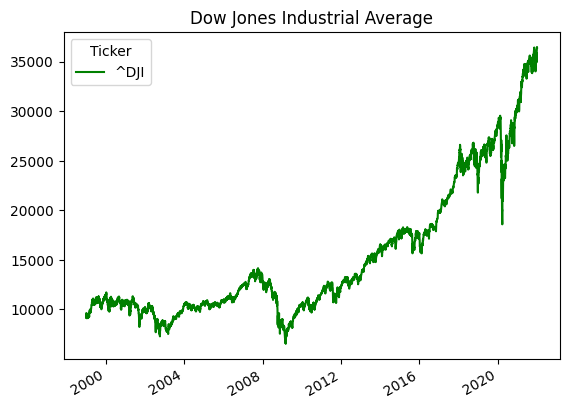

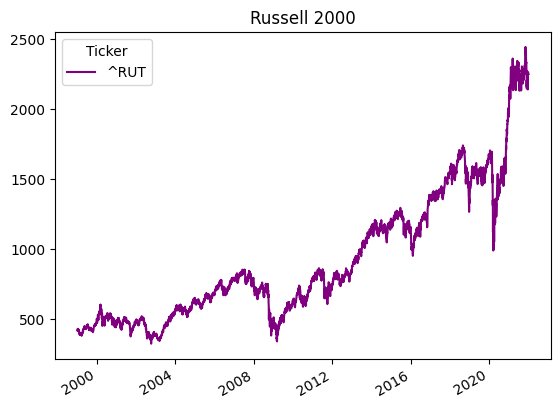

In [71]:
SP500.plot(y="Close", title="S&P 500")
NASDAQ.plot(y="Close", title="NASDAQ", color="orange")
DJIA.plot(y="Close", title="Dow Jones Industrial Average", color="green")
RUSSELL2000.plot(y="Close", title="Russell 2000", color="purple")
plt.show()

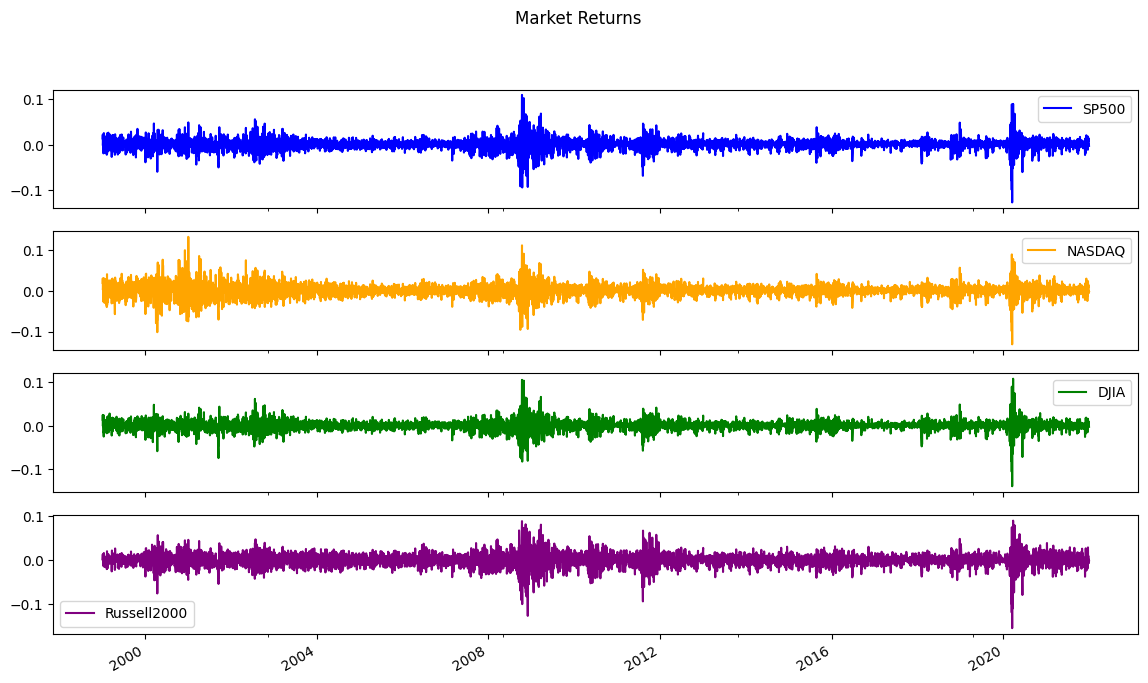

In [75]:
market_returns.plot(title="Market Returns", figsize=(14,8), color=["blue","orange","green","purple"], subplots=True)
plt.show()

## Conclusion

We successfully downloaded S&P 500, NASDAQ, DJIA and Russell 2000 prices and transformed them to log returns. Finally we proceed to show prices and returns graphics. Now we have the data to calculate the persistence diagrams in notebook 02.
